## Level 3 — Task 1: Predictive Modeling (Classification)

### Customer Churn Prediction

### Objective
The objective of this project is to build and compare multiple
classification models to predict whether a customer will churn.

The models evaluated are:
- Logistic Regression
- Decision Tree
- Random Forest

The models will be evaluated using accuracy, precision, recall,
F1-score, and confusion matrix. Hyperparameter tuning will then
be performed using GridSearchCV.


Import libraries 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

In [48]:
## Load Training and Testing Data
train_df = pd.read_csv("../../Data Set For Task-20260909T210001Z-1-001/Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv")

test_df = pd.read_csv("../../Data Set For Task-20260909T210001Z-1-001/Data Set For Task/Churn Prdiction Data/churn-bigml-20.csv")

In [49]:
#Data Quality Assessment
train_df.head()


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [50]:
test_df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
1,IN,65,415,No,No,0,129.1,137,21.95,228.5,83,19.42,208.8,111,9.40,12.7,6,3.43,4,True
2,NY,161,415,No,No,0,332.9,67,56.59,317.8,97,27.01,160.6,128,7.23,5.4,9,1.46,4,True
3,SC,111,415,No,No,0,110.4,103,18.77,137.3,102,11.67,189.6,105,8.53,7.7,6,2.08,2,False
4,HI,49,510,No,No,0,119.3,117,20.28,215.1,109,18.28,178.7,90,8.04,11.1,1,3.00,1,False


In [51]:
print("Training shape", train_df.shape)
print("Testing shape", test_df.shape)

Training shape (2666, 20)
Testing shape (667, 20)


In [52]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   str    
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   str    
 4   Voice mail plan         2666 non-null   str    
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   float64
 15

In [53]:
#Data Quality Assessment
train_df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [54]:
test_df.isnull().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [55]:
train_df.duplicated().sum()

np.int64(0)

In [56]:
test_df.duplicated().sum()

np.int64(0)

In [57]:
train_df['Churn'].value_counts()

Churn
False    2278
True      388
Name: count, dtype: int64

In [58]:
train_df['Churn'].value_counts(normalize=True)*100

Churn
False    85.446362
True     14.553638
Name: proportion, dtype: float64

In [59]:
test_df['Churn'].value_counts(normalize=True)*100

Churn
False    85.757121
True     14.242879
Name: proportion, dtype: float64

In [60]:
#Feature/Target Separation
X_train = train_df.drop(columns="Churn")
y_train = train_df["Churn"]

X_test = test_df.drop(columns="Churn")
y_test = test_df["Churn"]

In [61]:
train_df['Area code'] = train_df['Area code'].astype(str)
test_df['Area code'] = test_df['Area code'].astype(str)

In [62]:
#Categorical Encoding
X_train.select_dtypes(include=["object", "string"]).columns

Index(['State', 'International plan', 'Voice mail plan'], dtype='str')

In [63]:
#set dummy-variable columns

X_train = pd.get_dummies(X_train, drop_first=True)

X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [64]:
print(X_train.shape)
print(X_test.shape)

(2666, 68)
(667, 68)


In [65]:
#feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

#  Baseline Models
# Logistic Regression model

In [66]:

log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_scaled, y_train)

log_pred= log_model.predict(X_test_scaled)

In [67]:
print(classification_report(
    y_test, log_pred
))

              precision    recall  f1-score   support

       False       0.89      0.96      0.92       572
        True       0.51      0.25      0.34        95

    accuracy                           0.86       667
   macro avg       0.70      0.61      0.63       667
weighted avg       0.83      0.86      0.84       667



In [68]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print ("Accuracy :", log_accuracy)
print ("Precision :", log_precision)
print ("Recall :", log_recall)
print ("F1 Score :", log_f1)

Accuracy : 0.8590704647676162
Precision : 0.5106382978723404
Recall : 0.25263157894736843
F1 Score : 0.3380281690140845


# Decision Tree Classifier Model

In [69]:

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [70]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print ("Accuracy :", dt_accuracy)
print ("Precision :", dt_precision)
print ("Recall :", dt_recall)
print ("F1 Score :", dt_f1)

Accuracy : 0.9340329835082459
Precision : 0.7802197802197802
Recall : 0.7473684210526316
F1 Score : 0.7634408602150538


# Random Forest Model

In [71]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [72]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print ("Accuracy :", rf_accuracy)
print ("Precision :", rf_precision)
print ("Recall :", rf_recall)
print ("F1 Score :", rf_f1)

Accuracy : 0.9415292353823088
Precision : 0.9827586206896551
Recall : 0.6
F1 Score : 0.7450980392156863


In [73]:
# Baseline Model Comparison
model_results = pd.DataFrame(
    {
    "Model": [
        "Logestic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [log_accuracy, dt_accuracy, rf_accuracy],
    "Precision": [log_precision, dt_precision, rf_precision],
    "Recall": [log_recall, dt_recall, rf_recall],
    "F1 Score": [log_f1, dt_f1, rf_f1]
    }
)

model_results 

,Model,Accuracy,Precision,Recall,F1 Score
0,Logestic Regression,0.859070,0.510638,0.252632,0.338028
1,Decision Tree,0.934033,0.780220,0.747368,0.763441
2,Random Forest,0.941529,0.982759,0.600000,0.745098


In [74]:
#hyperparameter tuning with GridSearchCV
model_params = {
    'decision_tree': {'model': DecisionTreeClassifier(random_state=42),
                      'params': {
                          'max_depth': [3, 5, 7, 10, None],
                          'min_samples_split': [2, 5, 10],
                          'min_samples_leaf': [1, 2, 4],
                          'criterion': ['gini', 'entropy']
                      }
                     },
    'random_forest': {'model': RandomForestClassifier(random_state=42),
                      'params': {
                          'n_estimators': [100, 200],
                          'max_depth': [3, 5, 7, 10, None],
                          'min_samples_split': [2, 5, 10],
                          'min_samples_leaf': [1, 2, 4]
                      }
                     }
}


In [75]:
#Tuned Model Evaluation
scores = []
best_models = {}

for model_name, mp in model_params.items():

    clf = GridSearchCV(mp['model'], mp['params'], cv=5, scoring='f1', n_jobs=-1)

    clf.fit(X_train, y_train)
    best_models[model_name] = clf.best_estimator_
    
    scores.append({
        'model': model_name,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })


In [76]:
df_scores =pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])

df_scores

,model,best_score,best_params
0,decision_tree,0.759785,"{'criterion': 'gini', 'max_depth': 7, 'min_sam..."
1,random_forest,0.739312,"{'max_depth': None, 'min_samples_leaf': 1, 'mi..."


In [77]:
best_models

{'decision_tree': DecisionTreeClassifier(max_depth=7, random_state=42),
 'random_forest': RandomForestClassifier(min_samples_split=5, n_estimators=200, random_state=42)}

In [78]:
dt_tuned_pred = best_models['decision_tree'].predict(X_test)

rf_tuned_pred = best_models['random_forest'].predict(X_test)

In [79]:
#calculate test metrics for the tuned models

dt_tuned_accuracy = accuracy_score(y_test, dt_tuned_pred)
dt_tuned_precision = precision_score(y_test, dt_tuned_pred)
dt_tuned_recall = recall_score(y_test, dt_tuned_pred)
dt_tuned_f1 = f1_score(y_test, dt_tuned_pred)

In [80]:
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)
rf_tuned_precision = precision_score(y_test, rf_tuned_pred)
rf_tuned_recall = recall_score(y_test, rf_tuned_pred)
rf_tuned_f1 = f1_score(y_test, rf_tuned_pred) 

In [81]:
#comparison table for baseline vs tuned models
results = pd.DataFrame(
    {
        "Model": [
            "Decision Tree",
            "Random Forest",
            "Decision Tree (Tuned)",
            "Random Forest (Tuned)"
        ],
        "Accuracy": [dt_accuracy, rf_accuracy, dt_tuned_accuracy, rf_tuned_accuracy],
        "Precision": [dt_precision, rf_precision, dt_tuned_precision, rf_tuned_precision],
        "Recall": [dt_recall, rf_recall, dt_tuned_recall, rf_tuned_recall],
        "F1 Score": [dt_f1, rf_f1, dt_tuned_f1, rf_tuned_f1]
    }
)
  
results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.934033,0.780220,0.747368,0.763441
1,Random Forest,0.941529,0.982759,0.600000,0.745098
2,Decision Tree (Tuned),0.949025,0.850575,0.778947,0.813187
3,Random Forest (Tuned),0.947526,1.000000,0.631579,0.774194


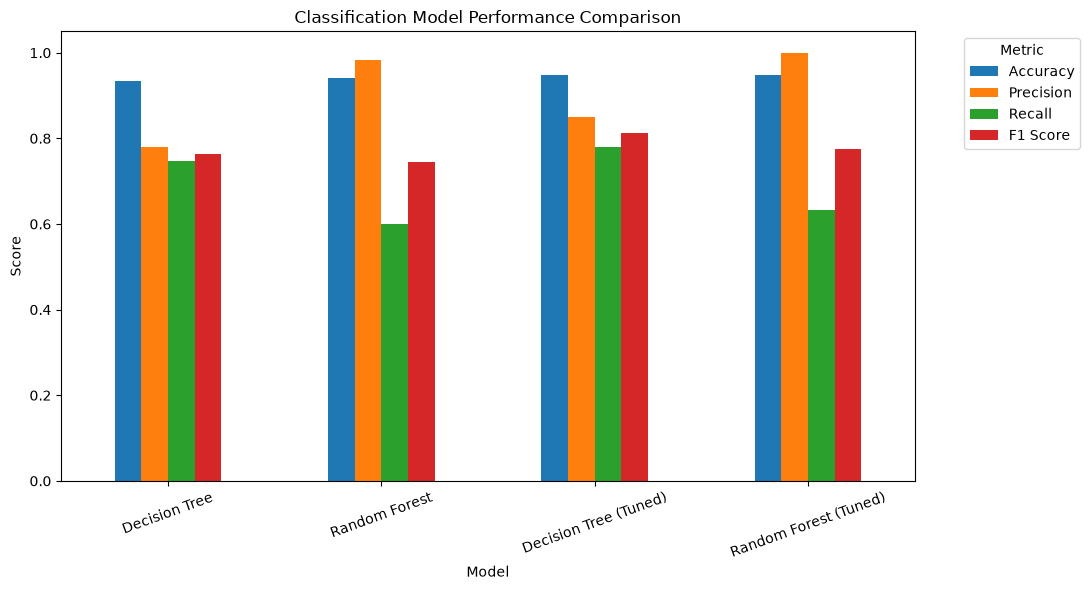

In [82]:
results_plot = results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score']
]

results_plot.plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Classification Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20)

plt.legend(
    title='Metric',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

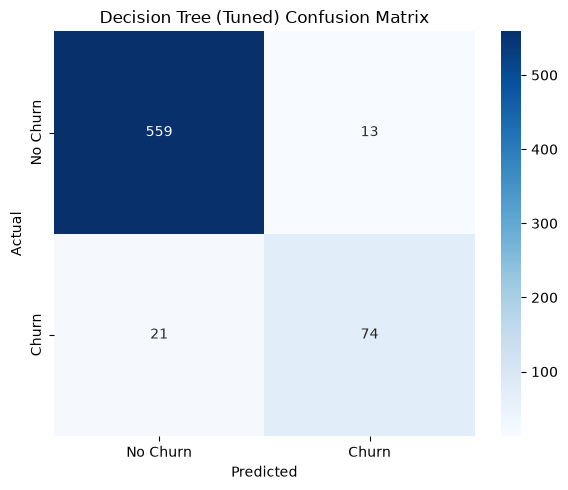

In [83]:
#confusion matrices for the tuned models

cm_dt_tuned = confusion_matrix(y_test, dt_tuned_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_dt_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.title('Decision Tree (Tuned) Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [84]:
#classification report for the tuned models
print(classification_report(y_test, dt_tuned_pred))

              precision    recall  f1-score   support

       False       0.96      0.98      0.97       572
        True       0.85      0.78      0.81        95

    accuracy                           0.95       667
   macro avg       0.91      0.88      0.89       667
weighted avg       0.95      0.95      0.95       667



In [85]:
print(classification_report(y_test, rf_tuned_pred))

              precision    recall  f1-score   support

       False       0.94      1.00      0.97       572
        True       1.00      0.63      0.77        95

    accuracy                           0.95       667
   macro avg       0.97      0.82      0.87       667
weighted avg       0.95      0.95      0.94       667



## Final Model Selection

After hyperparameter tuning, both the Decision Tree and Random Forest
models improved.

The Tuned Decision Tree achieved:

- Accuracy: 94.9%
- Precision: 85.1%
- Recall: 77.9%
- F1-score: 81.3%

The Tuned Random Forest achieved slightly lower accuracy and F1-score,
although it achieved perfect precision.

Because customer churn prediction requires identifying as many actual
churners as possible while maintaining reliable predictions, the Tuned
Decision Tree provides the strongest overall balance between precision
and recall.

Therefore, the Tuned Decision Tree was selected as the final model.


## Key Findings

1. The churn dataset is imbalanced, with considerably fewer churn
   customers than non-churn customers.

2. Logistic Regression showed relatively poor recall for the churn class,
   indicating that accuracy alone was not sufficient for model evaluation.

3. The baseline Decision Tree produced better recall and F1-score than
   the baseline Random Forest.

4. Hyperparameter tuning improved both Decision Tree and Random Forest
   performance.

5. The Tuned Decision Tree achieved the highest F1-score of approximately
   0.813 and recall of approximately 0.779.

6. The Tuned Random Forest achieved perfect precision for churn
   predictions but had lower recall, meaning it missed more actual churners.

## Conclusion

Three classification algorithms — Logistic Regression, Decision Tree,
and Random Forest — were developed and evaluated for customer churn
prediction.

Because the target class was imbalanced, accuracy was evaluated together
with precision, recall, and F1-score.

GridSearchCV was used to optimize the Decision Tree and Random Forest
models. Hyperparameter tuning improved the performance of both models.

The Tuned Decision Tree provided the strongest overall classification
performance, achieving approximately 94.9% accuracy, 85.1% precision,
77.9% recall, and an F1-score of 81.3%.

Therefore, the Tuned Decision Tree was selected as the final model for
this churn-classification analysis.